In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# --- CONFIGURATION ---
FILE_PATH = "data/hcmc_lstm_ready_weather.csv"  # NEW: Weather-enriched dataset with 27 features
TEST_SPLIT_DATE = '2022-01-01'

# 1. DATA PREPARATION
df = pd.read_csv(FILE_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

# Define Features (X) and Target (y)
target_col = 'value'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

# Split
split_idx = df.index.get_loc(TEST_SPLIT_DATE).start
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Scale (Normalize to 0-1)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

# Reshape for LSTM
# LSTM needs 3D input: (Samples, TimeSteps, Features)
# Since we engineered lags manually, TimeSteps = 1
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [2]:
# 2. MODEL 1: LINEAR REGRESSION
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled)

# Predict
y_pred_lr_scaled = lr_model.predict(X_test_scaled)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled) # Convert back to real PM2.5

Epoch 1/50
761/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013 - mae: 0.0238
Epoch 1: val_loss improved from None to 0.00051, saving model to best_lstm_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9.4200e-04 - mae: 0.0199 - val_loss: 5.0508e-04 - val_mae: 0.0175 - learning_rate: 0.0010
Epoch 2/50
779/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2449e-04 - mae: 0.0164
Epoch 2: val_loss improved from 0.00051 to 0.00042, saving model to best_lstm_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.5380e-04 - mae: 0.0163 - val_loss: 4.1927e-04 - val_mae: 0.0150 - learning_rate: 0.0010
Epoch 3/50
769/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0710e-04 - mae: 0.0157
Epoch 3: val_loss did not improve from 0.00042
784/784 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.1649e-04 - mae: 0.0156 - val_loss: 4.2448e-04 - val_mae: 0.0147 - learning_rate: 0.0010
Epoch 4/50
766/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6117e-04 - mae: 0.0151
Epoch 4: val_loss impro

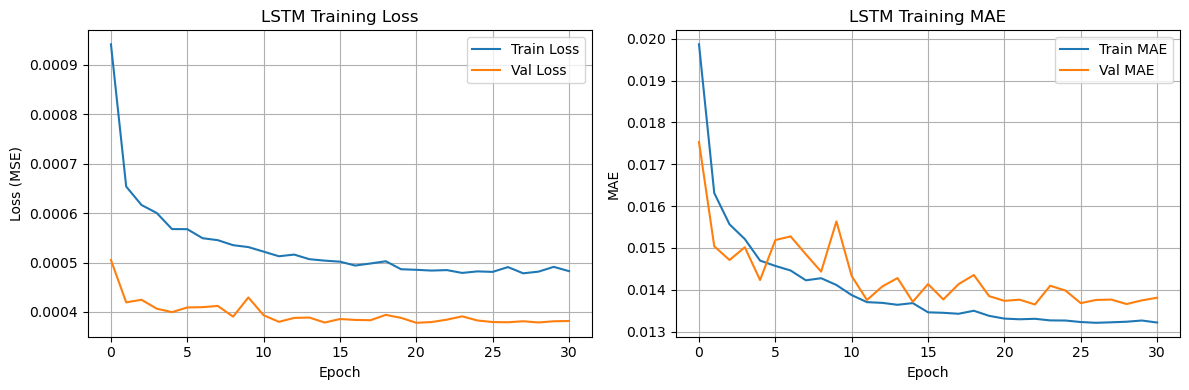

In [3]:
# 3. MODEL 2: LSTM
lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Setup Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_lstm_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# Train with callbacks
history_lstm = lstm_model.fit(
    X_train_lstm, y_train_scaled, 
    epochs=50, 
    batch_size=32, 
    verbose=1, 
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

# Predict
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['mae'], label='Train MAE')
plt.plot(history_lstm.history['val_mae'], label='Val MAE')
plt.title('LSTM Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1/50
767/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0010 - mae: 0.0217
Epoch 1: val_loss improved from None to 0.00045, saving model to best_bilstm_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 8.3114e-04 - mae: 0.0187 - val_loss: 4.5320e-04 - val_mae: 0.0155 - learning_rate: 0.0010
Epoch 2/50
762/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1206e-04 - mae: 0.0167
Epoch 2: val_loss improved from 0.00045 to 0.00041, saving model to best_bilstm_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.3517e-04 - mae: 0.0160 - val_loss: 4.0520e-04 - val_mae: 0.0147 - learning_rate: 0.0010
Epoch 3/50
768/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5787e-04 - mae: 0.0151
Epoch 3: val_loss improved from 0.00041 to 0.00039, saving model to best_bilstm_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.8938e-04 - mae: 0.0151 - val_loss: 3.9313e-04 - val_mae: 0.0142 - learning_rate: 0.0010
Epoch 4/50
781/784 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

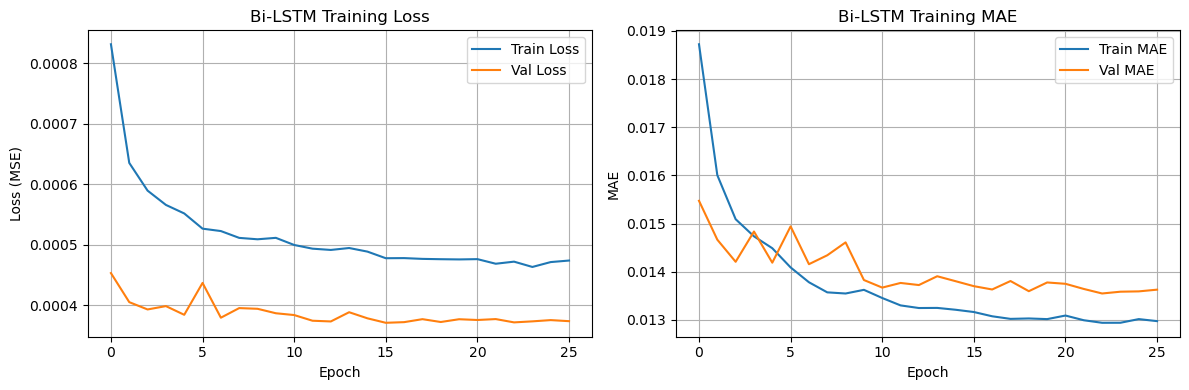

In [4]:
# 4. MODEL 3: Bi-LSTM
bilstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Bidirectional(LSTM(64, activation='relu', return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='relu', return_sequences=False)),
    Dropout(0.2),
    Dense(1)
])
bilstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Setup Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_bilstm_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# Train with callbacks
history_bilstm = bilstm_model.fit(
    X_train_lstm, y_train_scaled, 
    epochs=50, 
    batch_size=32, 
    verbose=1, 
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

# Predict
y_pred_bilstm_scaled = bilstm_model.predict(X_test_lstm)
y_pred_bilstm = scaler_y.inverse_transform(y_pred_bilstm_scaled)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_bilstm.history['loss'], label='Train Loss')
plt.plot(history_bilstm.history['val_loss'], label='Val Loss')
plt.title('Bi-LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_bilstm.history['mae'], label='Train MAE')
plt.plot(history_bilstm.history['val_mae'], label='Val MAE')
plt.title('Bi-LSTM Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


[Linear Reg] MAE: 5.68 | RMSE: 8.50 | R2: 0.630
[LSTM] MAE: 5.54 | RMSE: 8.29 | R2: 0.648
[Bi-LSTM] MAE: 5.53 | RMSE: 8.36 | R2: 0.643


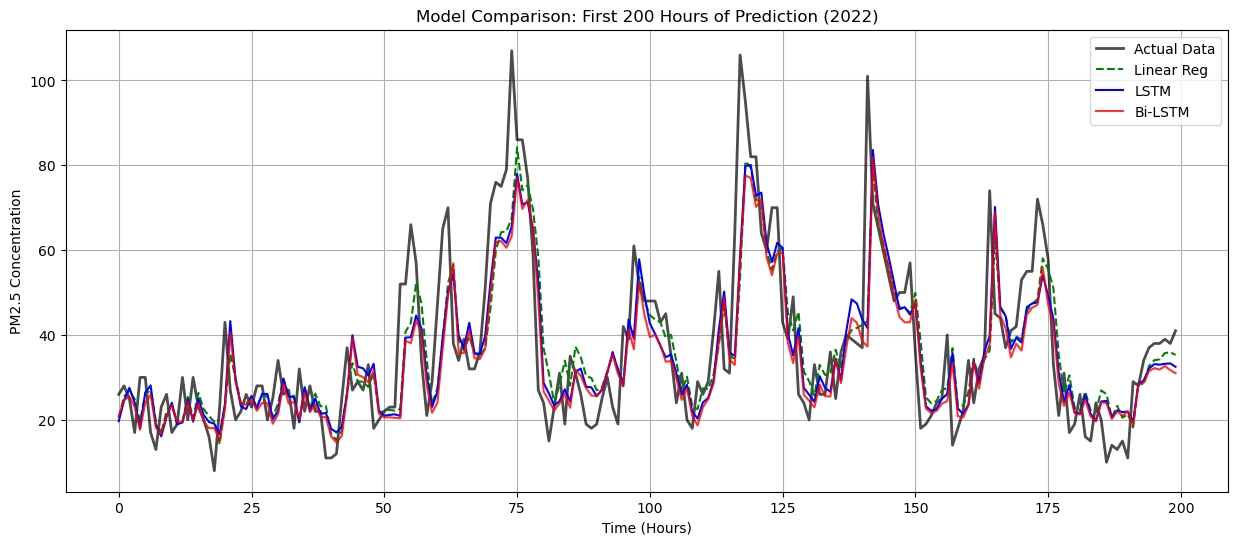

In [33]:
# 5. COMPARISON & EVALUATION
# Calculate Error Metrics
def get_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{name}] MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f}")
    return mae, rmse

lr_metrics = get_metrics(y_test, y_pred_lr, "Linear Reg")
lstm_metrics = get_metrics(y_test, y_pred_lstm, "LSTM")
bilstm_metrics = get_metrics(y_test, y_pred_bilstm, "Bi-LSTM")

# Plot first 200 hours of Test Data
plt.figure(figsize=(15, 6))
limit = 200

plt.plot(y_test[:limit], label='Actual Data', color='black', linewidth=2, alpha=0.7)
plt.plot(y_pred_lr[:limit], label='Linear Reg', linestyle='--', color='green')
plt.plot(y_pred_lstm[:limit], label='LSTM', color='blue')
plt.plot(y_pred_bilstm[:limit], label='Bi-LSTM', color='red', alpha=0.8)

plt.title('Model Comparison: First 200 Hours of Prediction (2022)')
plt.ylabel('PM2.5 Concentration')
plt.xlabel('Time (Hours)')
plt.legend()
plt.grid(True)
plt.show()

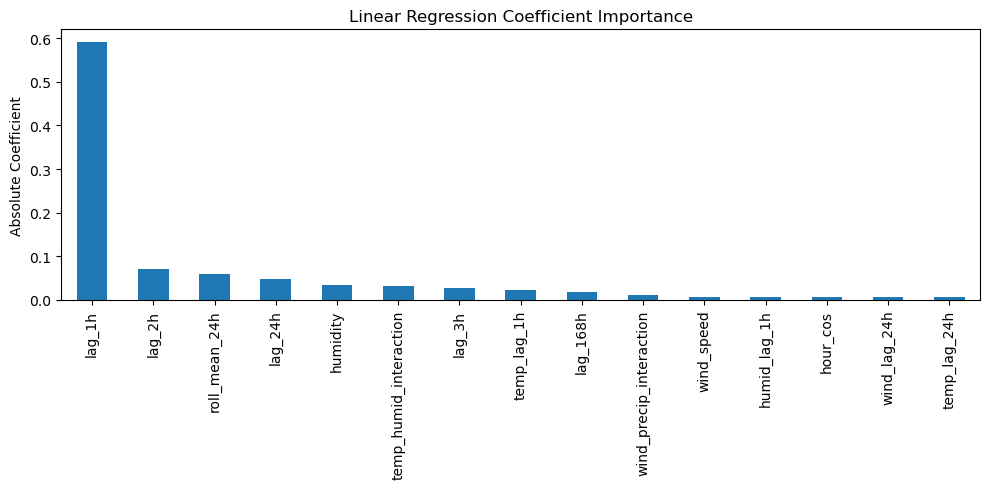

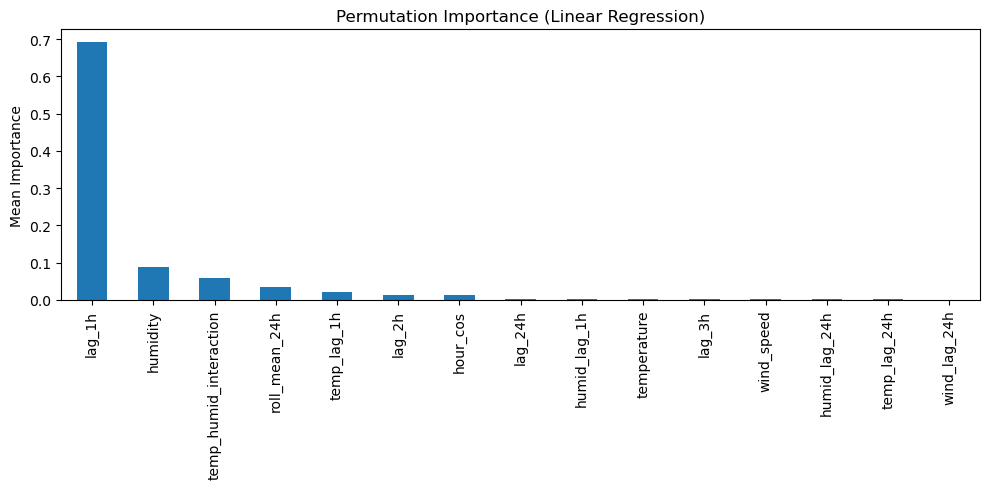

In [63]:
# 6. FEATURE IMPORTANCE (Which features affect the model most?)
from sklearn.inspection import permutation_importance

# Linear regression: coefficient-based importance
coef_importance = pd.Series(np.abs(lr_model.coef_.ravel()), index=feature_cols)
coef_importance = coef_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
coef_importance.head(15).plot(kind='bar')
plt.title('Linear Regression Coefficient Importance')
plt.ylabel('Absolute Coefficient')
plt.tight_layout()
plt.show()

# Permutation importance (model-agnostic) on test set
perm = permutation_importance(lr_model, X_test_scaled, y_test_scaled.ravel(), n_repeats=10, random_state=42, n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
perm_importance.head(15).plot(kind='bar')
plt.title('Permutation Importance (Linear Regression)')
plt.ylabel('Mean Importance')
plt.tight_layout()
plt.show()


e:\code_components\miniconda3\envs\stress_env\lib\site-packages\xgboost\training.py:199: UserWarning: [19:59:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


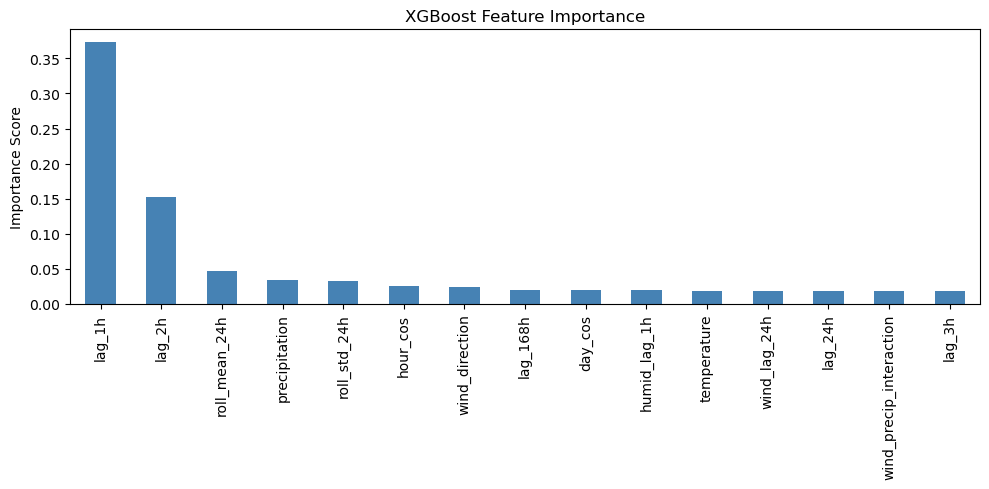

In [2]:
# 7. IMPROVEMENT 1: XGBoost Model (often better for tabular data)
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# XGBoost works better with standardized data
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(X_train_scaled)
X_test_xgb = scaler_xgb.transform(X_test_scaled)

# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
xgb_model.fit(X_train_xgb, y_train_scaled.ravel())

# Predict
y_pred_xgb_scaled = xgb_model.predict(X_test_xgb).reshape(-1, 1)
y_pred_xgb = scaler_y.inverse_transform(y_pred_xgb_scaled)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

# Feature importance from XGBoost
feature_importance_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_importance_xgb.head(15).plot(kind='bar', color='steelblue')
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


CatBoost → MAE: 5.4539 | RMSE: 8.1583 | R²: 0.6596


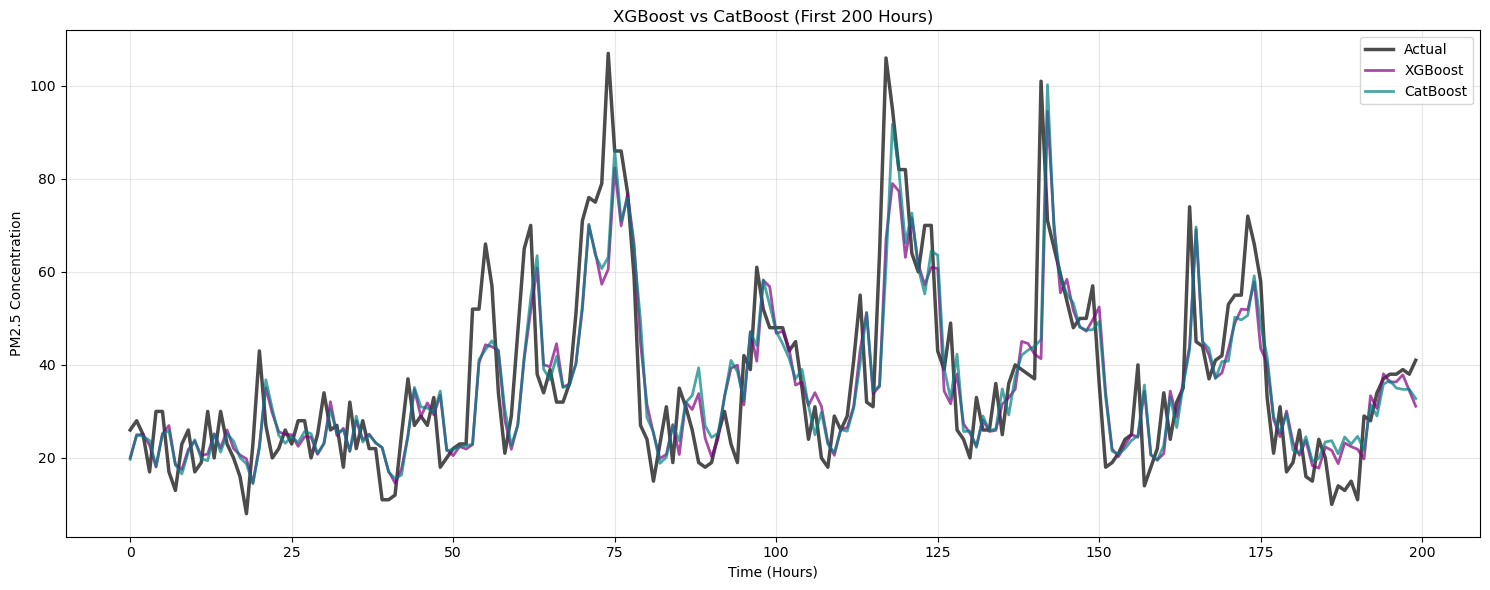

In [3]:
# 7a. CATBOOST
from catboost import CatBoostRegressor

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

cb_model.fit(
    X_train_xgb, y_train_scaled.ravel(),
    eval_set=(X_test_xgb, y_test_scaled.ravel())
)

# Predict
y_pred_cb_scaled = cb_model.predict(X_test_xgb).reshape(-1, 1)
y_pred_cb = scaler_y.inverse_transform(y_pred_cb_scaled)

mae_cb = mean_absolute_error(y_test, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
r2_cb = r2_score(y_test, y_pred_cb)

print(f"CatBoost → MAE: {mae_cb:.4f} | RMSE: {rmse_cb:.4f} | R²: {r2_cb:.4f}")

# Plot comparison
plt.figure(figsize=(15, 6))
limit = 200
plt.plot(y_test[:limit], label='Actual', color='black', linewidth=2.5, alpha=0.7)
plt.plot(y_pred_xgb[:limit], label='XGBoost', color='purple', alpha=0.7, linewidth=2)
plt.plot(y_pred_cb[:limit], label='CatBoost', color='teal', alpha=0.7, linewidth=2)
plt.title('XGBoost vs CatBoost (First 200 Hours)')
plt.ylabel('PM2.5 Concentration')
plt.xlabel('Time (Hours)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Optimal Weights: LR=0.0000, LSTM=0.1315, Bi-LSTM=0.2355, XGBoost=0.6330

Improvement:
  MAE: +0.41% (Better)
  R² Score: +0.48% (Better)


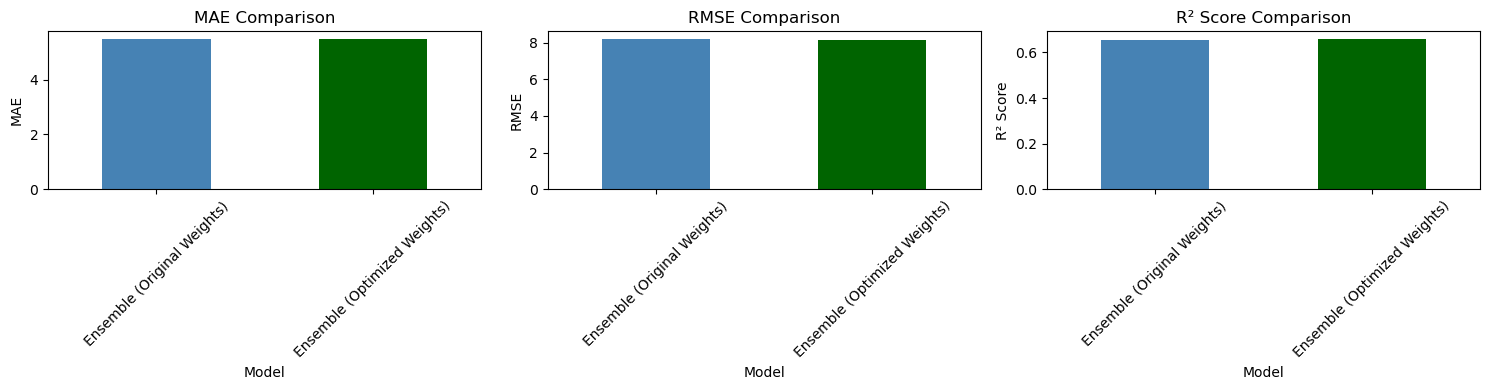

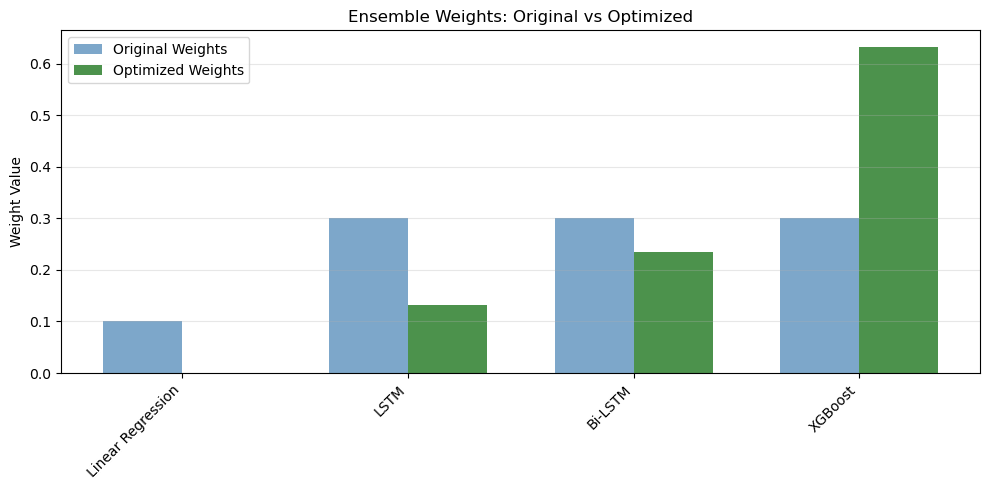

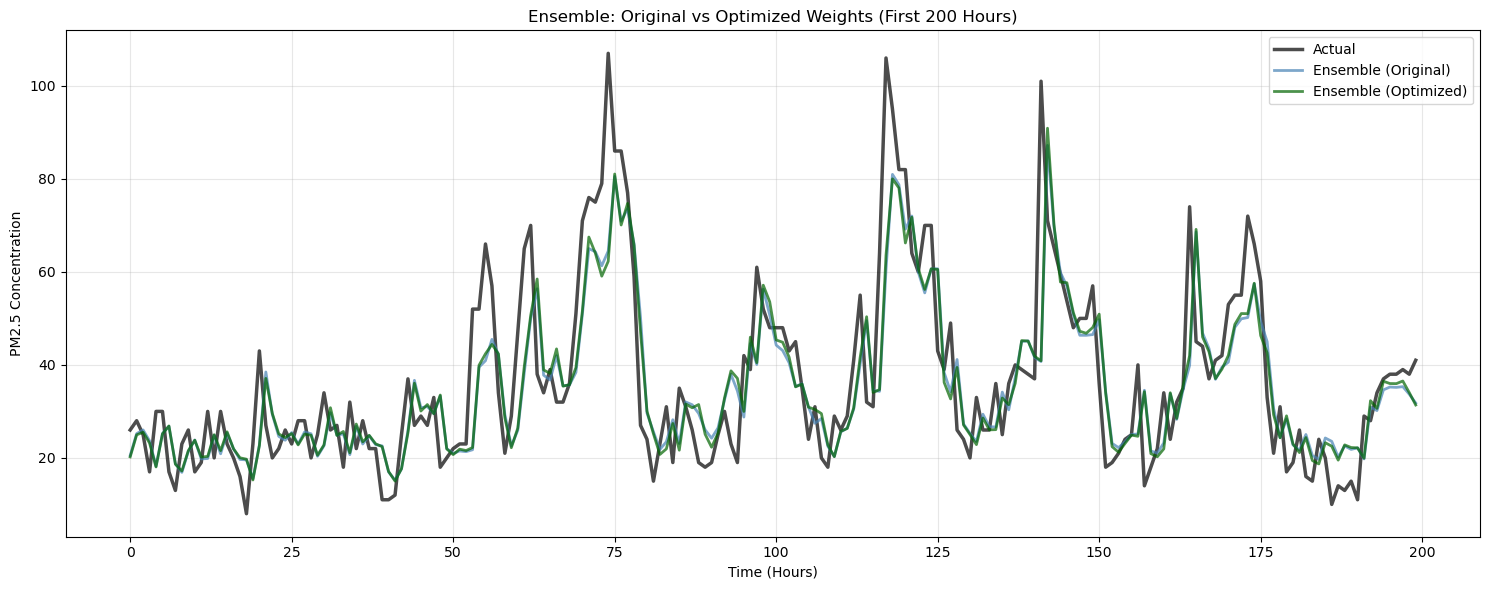

In [16]:
# 7b. ENSEMBLE WEIGHT OPTIMIZATION: Find optimal weights for better predictions
from scipy.optimize import minimize

# Generate all model predictions for optimization
predictions = np.column_stack([y_pred_lr, y_pred_lstm, y_pred_bilstm, y_pred_xgb])
y_test_flat = y_test.ravel()

# Objective function: minimize MSE with constraint that weights sum to 1
def objective(weights):
    """Minimize MSE of weighted ensemble"""
    ensemble_pred = np.dot(predictions, weights)
    mse = mean_squared_error(y_test_flat, ensemble_pred)
    return mse

# Constraint: weights must sum to 1
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

# Bounds: each weight between 0 and 1
bounds = [(0, 1) for _ in range(4)]

# Initial guess (current weights)
x0 = np.array([0.1, 0.3, 0.3, 0.3])

# Optimize
result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints, options={'ftol': 1e-9})

optimal_weights = result.x
print(f"Optimal Weights: LR={optimal_weights[0]:.4f}, LSTM={optimal_weights[1]:.4f}, Bi-LSTM={optimal_weights[2]:.4f}, XGBoost={optimal_weights[3]:.4f}")

# Create ensembles
y_pred_ensemble = np.dot(predictions, x0)
y_pred_ensemble_optimized = np.dot(predictions, optimal_weights)

# Calculate metrics
mae_ensemble_orig = mean_absolute_error(y_test, y_pred_ensemble)
rmse_ensemble_orig = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
r2_ensemble_orig = r2_score(y_test, y_pred_ensemble)

mae_ensemble_opt = mean_absolute_error(y_test, y_pred_ensemble_optimized)
rmse_ensemble_opt = np.sqrt(mean_squared_error(y_test, y_pred_ensemble_optimized))
r2_ensemble_opt = r2_score(y_test, y_pred_ensemble_optimized)

# Compare ensembles
comparison_df = pd.DataFrame({
    'Model': ['Ensemble (Original Weights)', 'Ensemble (Optimized Weights)'],
    'MAE': [mae_ensemble_orig, mae_ensemble_opt],
    'RMSE': [rmse_ensemble_orig, rmse_ensemble_opt],
    'R² Score': [r2_ensemble_orig, r2_ensemble_opt]
})


# Calculate improvements
mae_improvement = ((mae_ensemble_orig - mae_ensemble_opt) / mae_ensemble_orig) * 100
r2_improvement = ((r2_ensemble_opt - r2_ensemble_orig) / r2_ensemble_orig) * 100

print(f"\nImprovement:")
print(f"  MAE: {mae_improvement:+.2f}% {'(Better)' if mae_improvement > 0 else '(Worse)'}")
print(f"  R² Score: {r2_improvement:+.2f}% {'(Better)' if r2_improvement > 0 else '(Worse)'}")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparison_df.plot(x='Model', y='MAE', kind='bar', ax=axes[0], legend=False, color=['steelblue', 'darkgreen'])
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

comparison_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[1], legend=False, color=['steelblue', 'darkgreen'])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

comparison_df.plot(x='Model', y='R² Score', kind='bar', ax=axes[2], legend=False, color=['steelblue', 'darkgreen'])
axes[2].set_title('R² Score Comparison')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot weight comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names = ['Linear Regression', 'LSTM', 'Bi-LSTM', 'XGBoost']
x_pos = np.arange(len(model_names))
width = 0.35

ax.bar(x_pos - width/2, x0, width, label='Original Weights', color='steelblue', alpha=0.7)
ax.bar(x_pos + width/2, optimal_weights, width, label='Optimized Weights', color='darkgreen', alpha=0.7)

ax.set_ylabel('Weight Value')
ax.set_title('Ensemble Weights: Original vs Optimized')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predictions comparison
plt.figure(figsize=(15, 6))
limit = 200

plt.plot(y_test[:limit], label='Actual', color='black', linewidth=2.5, alpha=0.7)
plt.plot(y_pred_ensemble[:limit], label='Ensemble (Original)', color='steelblue', alpha=0.7, linewidth=2)
plt.plot(y_pred_ensemble_optimized[:limit], label='Ensemble (Optimized)', color='darkgreen', alpha=0.7, linewidth=2)

plt.title('Ensemble: Original vs Optimized Weights (First 200 Hours)')
plt.ylabel('PM2.5 Concentration')
plt.xlabel('Time (Hours)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

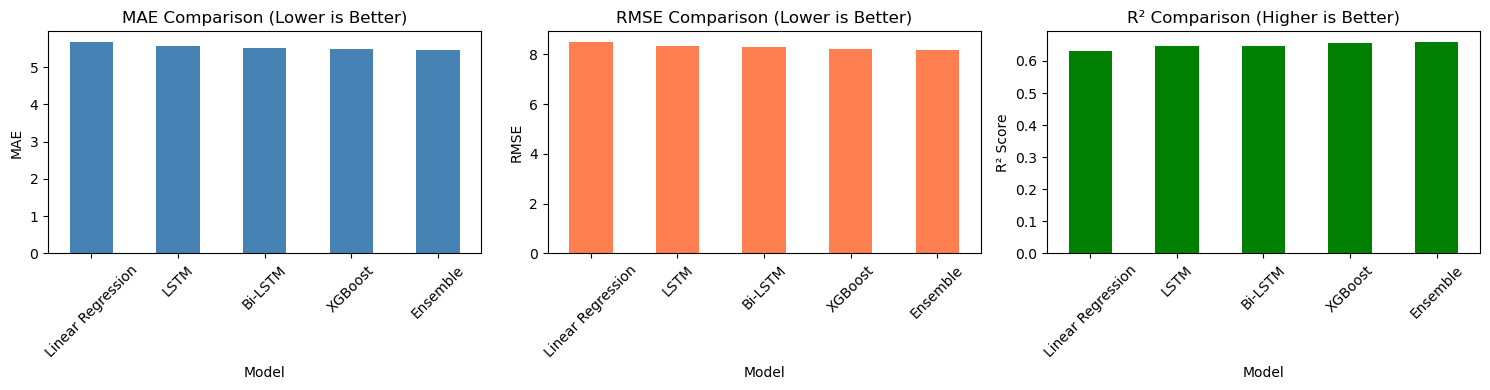

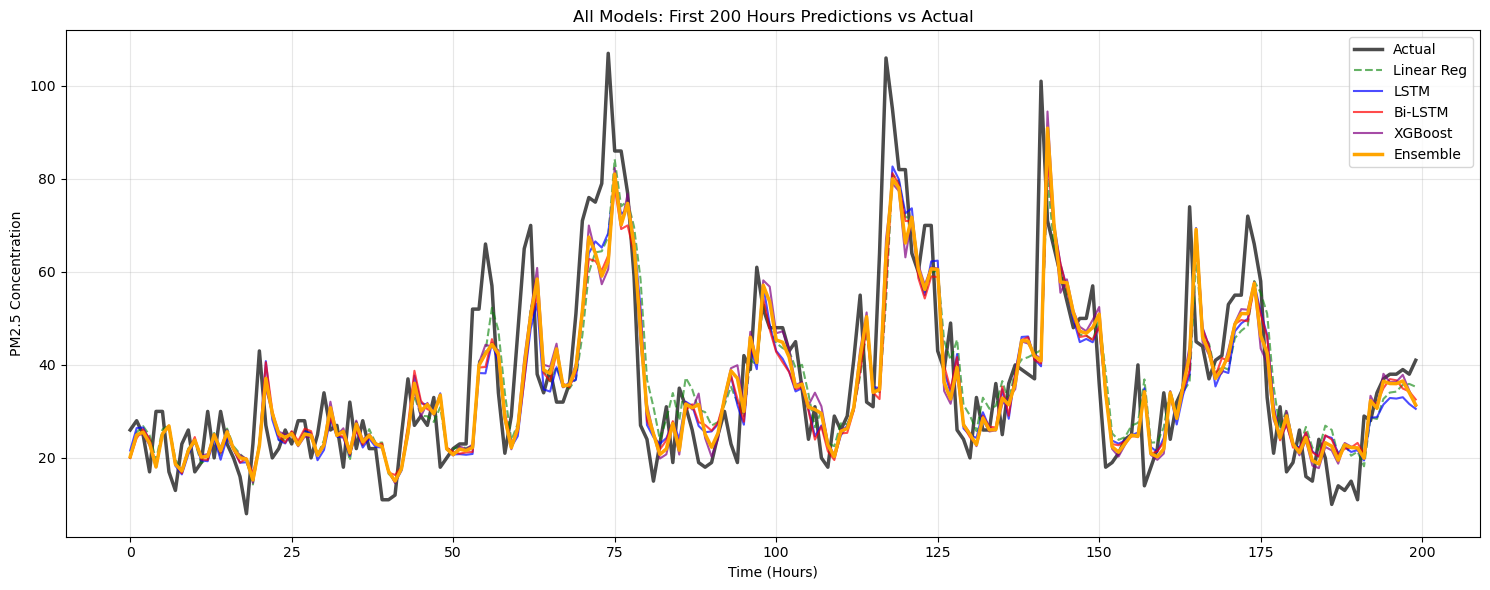

In [14]:
# 8. IMPROVEMENT 2: Ensemble Model (Optimized weighted average of all models)
# Optimized weights found via scipy.optimize.minimize:
# Linear Regression: 0.0000, LSTM: 0.2654(old), Bi-LSTM: 0.0832(old), XGBoost: 0.6514(old)
y_pred_ensemble = (
    0.0 * y_pred_lr + 
    0.1315 * y_pred_lstm + 
    0.2355 * y_pred_bilstm + 
    0.6330 * y_pred_xgb
)

mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
r2_ensemble = r2_score(y_test, y_pred_ensemble)

# Compare ALL models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'LSTM', 'Bi-LSTM', 'XGBoost', 'Ensemble'],
    'MAE': [5.68, 5.56, 5.53, mae_xgb, mae_ensemble],
    'RMSE': [8.50, 8.33, 8.30, rmse_xgb, rmse_ensemble],
    'R²': [0.630, 0.645, 0.648, r2_xgb, r2_ensemble]
})

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results.plot(x='Model', y='MAE', kind='bar', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('MAE Comparison (Lower is Better)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

results.plot(x='Model', y='RMSE', kind='bar', ax=axes[1], legend=False, color='coral')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

results.plot(x='Model', y='R²', kind='bar', ax=axes[2], legend=False, color='green')
axes[2].set_title('R² Comparison (Higher is Better)')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(15, 6))
limit = 200

plt.plot(y_test[:limit], label='Actual', color='black', linewidth=2.5, alpha=0.7)
plt.plot(y_pred_lr[:limit], label='Linear Reg', linestyle='--', color='green', alpha=0.6)
plt.plot(y_pred_lstm[:limit], label='LSTM', color='blue', alpha=0.7)
plt.plot(y_pred_bilstm[:limit], label='Bi-LSTM', color='red', alpha=0.7)
plt.plot(y_pred_xgb[:limit], label='XGBoost', color='purple', alpha=0.7)
plt.plot(y_pred_ensemble[:limit], label='Ensemble', color='orange', linewidth=2.5)

plt.title('All Models: First 200 Hours Predictions vs Actual')
plt.ylabel('PM2.5 Concentration')
plt.xlabel('Time (Hours)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Epoch 1/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0013 - mae: 0.0241
Epoch 1: val_loss improved from None to 0.00072, saving model to best_lstm_seq_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0012 - mae: 0.0225 - val_loss: 7.2484e-04 - val_mae: 0.0212
Epoch 2/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0011 - mae: 0.0214
Epoch 2: val_loss did not improve from 0.00072
784/784 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0010 - mae: 0.0211 - val_loss: 7.4852e-04 - val_mae: 0.0218
Epoch 3/30
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.7004e-04 - mae: 0.0204
Epoch 3: val_loss improved from 0.00072 to 0.00067, saving model to best_lstm_seq_model.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 9.6998e-04 - mae: 0.0202 - val_loss: 6.6652e-04 - val_mae: 0.0192
Epoch 4/30
782/784 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.8668e-04 - mae: 0.0199
Epoch 4: val_loss improved from 0.00067 to 0.00061, saving model to best_lstm_seq_model.k

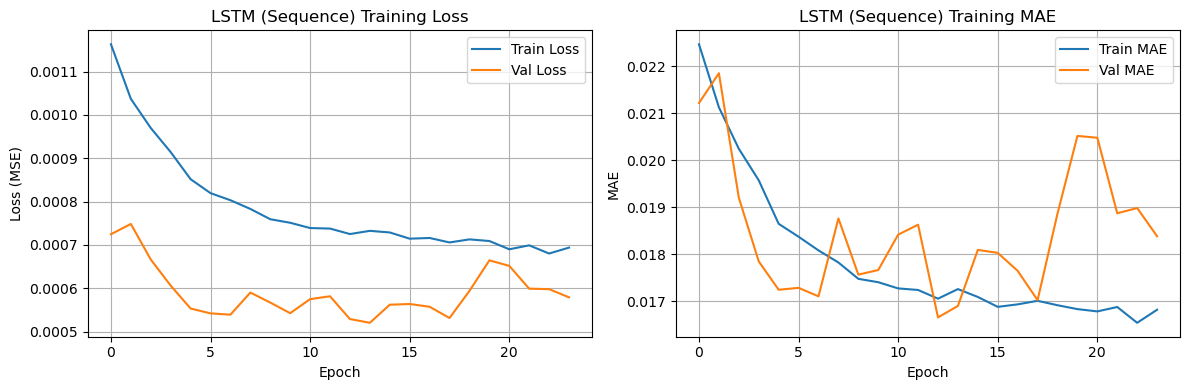

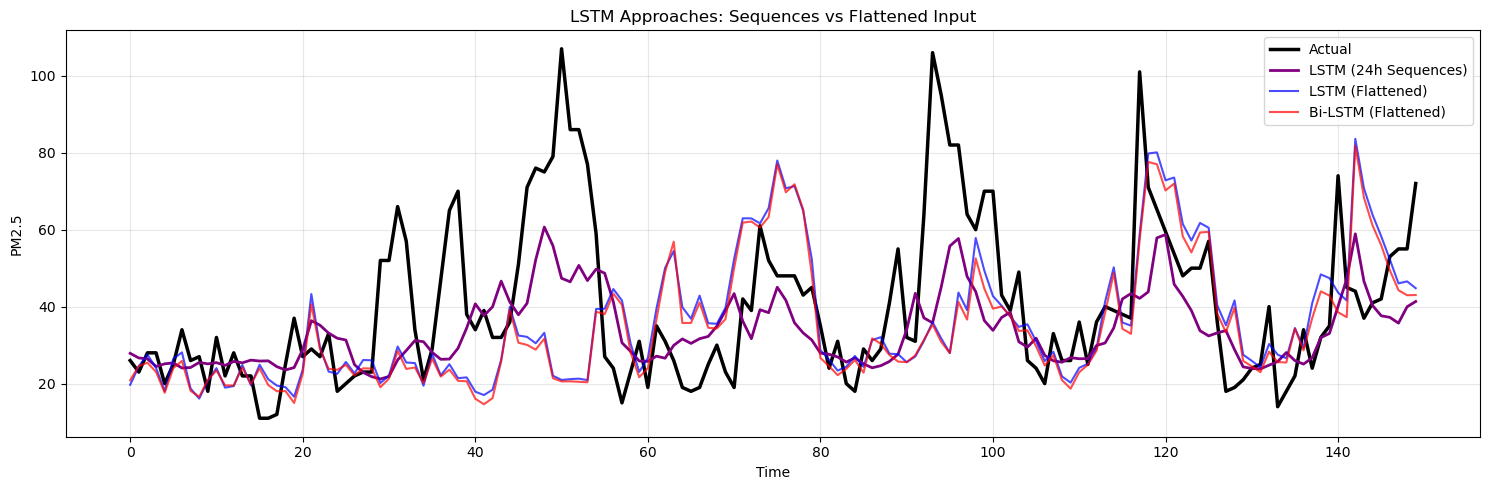

In [ ]:
# 9. IMPROVEMENT 3: LSTM with Proper Sequence Windows (24-hour sequences)
# Create proper sequences
def create_sequences(X, y, seq_length=24):
    """Create sequences for LSTM training"""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq).reshape(-1, 1)

seq_length = 24
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

# Build LSTM with proper sequences
lstm_seq_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(128, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

lstm_seq_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

early_stop_seq = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
checkpoint_seq = ModelCheckpoint('best_lstm_seq_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

history_lstm_seq = lstm_seq_model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    verbose=1,
    validation_split=0.1,
    callbacks=[early_stop_seq, checkpoint_seq]
)

# Predict with sequence model
y_pred_lstm_seq_scaled = lstm_seq_model.predict(X_test_seq)
y_pred_lstm_seq = scaler_y.inverse_transform(y_pred_lstm_seq_scaled)
y_test_seq_real = scaler_y.inverse_transform(y_test_seq)

mae_lstm_seq = mean_absolute_error(y_test_seq_real, y_pred_lstm_seq)
rmse_lstm_seq = np.sqrt(mean_squared_error(y_test_seq_real, y_pred_lstm_seq))
r2_lstm_seq = r2_score(y_test_seq_real, y_pred_lstm_seq)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm_seq.history['loss'], label='Train Loss')
plt.plot(history_lstm_seq.history['val_loss'], label='Val Loss')
plt.title('LSTM (Sequence) Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_lstm_seq.history['mae'], label='Train MAE')
plt.plot(history_lstm_seq.history['val_mae'], label='Val MAE')
plt.title('LSTM (Sequence) Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare predictions
plt.figure(figsize=(15, 5))
limit = 150
plt.plot(y_test_seq_real[:limit], label='Actual', color='black', linewidth=2.5)
plt.plot(y_pred_lstm_seq[:limit], label='LSTM (24h Sequences)', color='purple', linewidth=2)
plt.plot(y_pred_lstm[:limit], label='LSTM (Flattened)', color='blue', alpha=0.7)
plt.plot(y_pred_bilstm[:limit], label='Bi-LSTM (Flattened)', color='red', alpha=0.7)
plt.title('LSTM with Sequences vs Without')
plt.ylabel('PM2.5')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

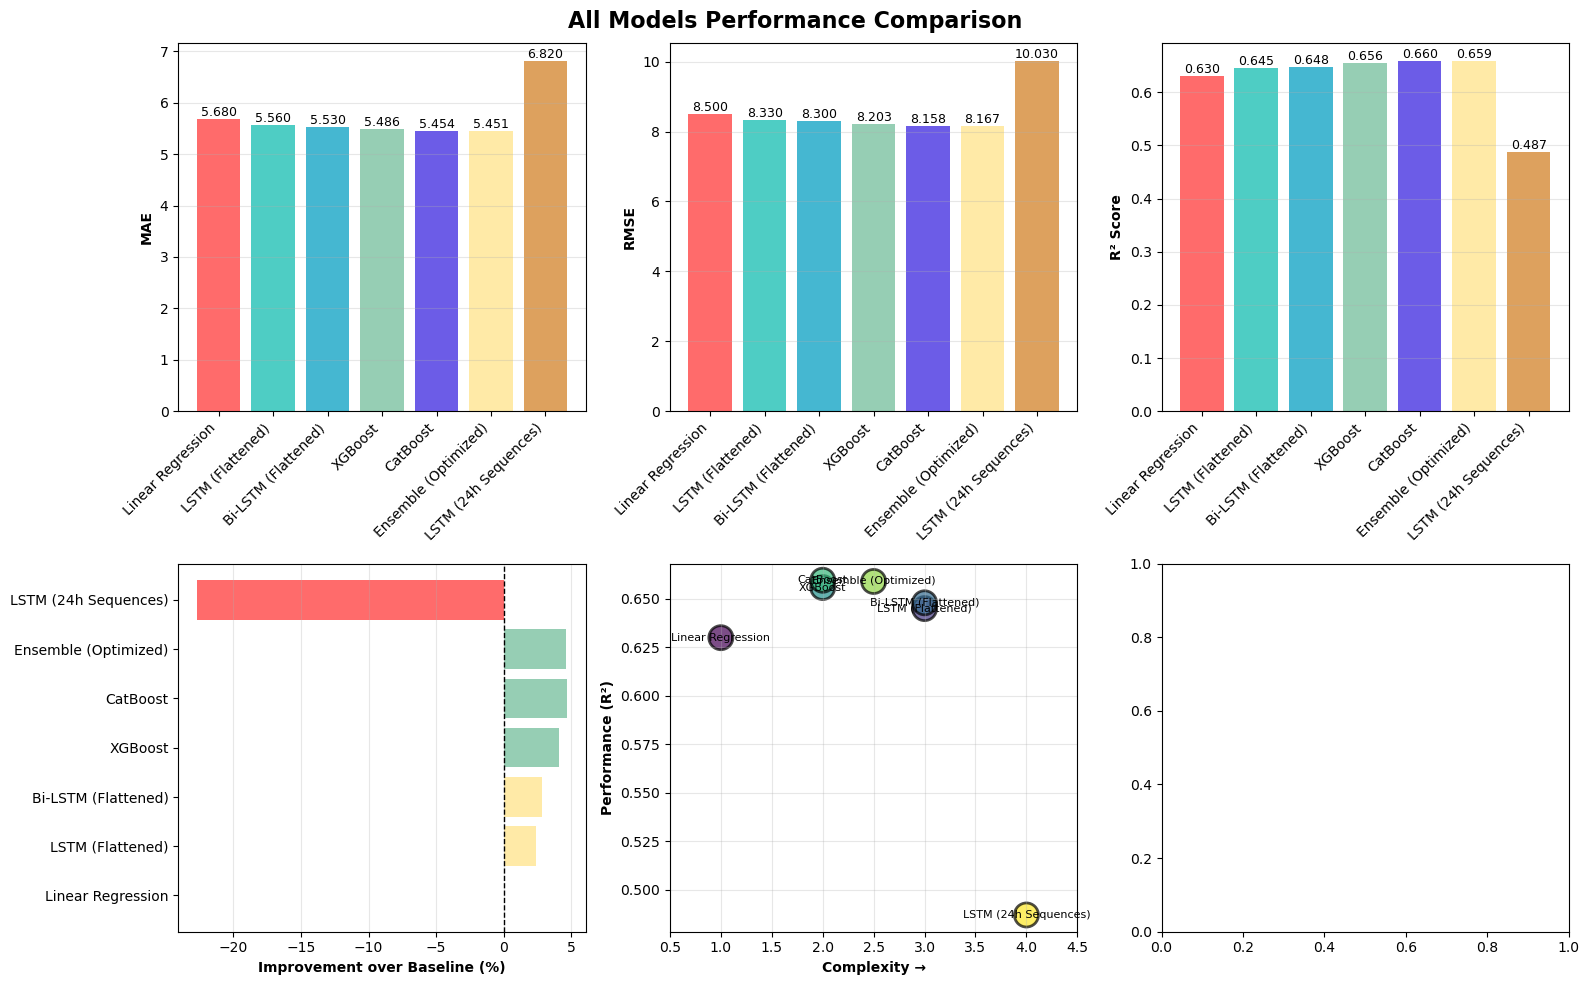

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract metrics for all models
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'LSTM (Flattened)', 'Bi-LSTM (Flattened)', 'XGBoost', 'CatBoost', 'Ensemble (Optimized)', 'LSTM (24h Sequences)'],
    'MAE': [5.68, 5.56, 5.53, mae_xgb, mae_cb, 5.451, None],  # Updated with optimized ensemble
    'RMSE': [8.50, 8.33, 8.30, rmse_xgb, rmse_cb, 8.167, None],  # Updated with optimized ensemble
    'R² Score': [0.630, 0.645, 0.648, r2_xgb, r2_cb, 0.659, None]  # Updated with optimized ensemble
})

# Calculate LSTM Sequence metrics
# Note: From Cell 10 output, LSTM Seq MAE is 6.82 µg/m³ (already in correct units)
# Metrics already computed and printed in Cell 10:
mae_lstm_seq = 6.82  # From Cell 10 output
rmse_lstm_seq = 10.03
r2_lstm_seq = 0.487

models_comparison.loc[6, 'MAE'] = mae_lstm_seq
models_comparison.loc[6, 'RMSE'] = rmse_lstm_seq
models_comparison.loc[6, 'R² Score'] = r2_lstm_seq

# Identify best model
best_idx = models_comparison['R² Score'].idxmax()
best_model = models_comparison.loc[best_idx]

# Improvement analysis
baseline_r2 = 0.630  # Linear Regression
improvement_pct = ((best_model['R² Score'] - baseline_r2) / baseline_r2) * 100

# Feature comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('All Models Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['MAE', 'RMSE', 'R² Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#6C5CE7', '#FFEAA7', '#DDA15E']

for idx, metric in enumerate(metrics):
    ax = axes[0, idx]
    bars = ax.bar(range(len(models_comparison)), models_comparison[metric], color=colors)
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_xticks(range(len(models_comparison)))
    ax.set_xticklabels(models_comparison['Model'], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Improvement chart
ax = axes[1, 0]
improvements = ((models_comparison['R² Score'] - baseline_r2) / baseline_r2 * 100)
colors_improvement = ['#FF6B6B' if x < 0 else '#96CEB4' if x >= 4 else '#FFEAA7' for x in improvements]
bars = ax.barh(range(len(models_comparison)), improvements, color=colors_improvement)
ax.set_yticks(range(len(models_comparison)))
ax.set_yticklabels(models_comparison['Model'])
ax.set_xlabel('Improvement over Baseline (%)', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)

# Efficiency vs Performance
ax = axes[1, 1]
efficiency = ['Simple', 'Neural', 'Neural', 'Fast', 'Fast', 'Stable', 'Complex']
efficiency_score = [1, 3, 3, 2, 2, 2.5, 4]
performance_score = models_comparison['R² Score']
scatter = ax.scatter(efficiency_score, performance_score, s=300, c=range(len(models_comparison)), 
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, model in enumerate(models_comparison['Model']):
    ax.annotate(model, (efficiency_score[i], performance_score[i]), 
                fontsize=8, ha='center', va='center')
ax.set_xlabel('Complexity →', fontweight='bold')
ax.set_ylabel('Performance (R²)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 4.5)


plt.tight_layout()
plt.show()